# Motor Controller SNN with e-prop (NEST)

This notebook demonstrates how to use the motor controller spiking neural network (SNN) model implemented in NEST Simulator ([repository link](https://github.com/shimoura/motor-controller-model/tree/add-nestml-neurons/eprop-motor-control)). The network models motor cortex (M1) activity for a movement task, using e-prop learning as implemented in NEST.

Here is presented how to:
- Set up and run the simulation for a motor controller network using joint angle trajectories (robot arm as a reference)
- Analyze spike trains, output signals, and the loss curve

> **Note:** This notebook is intended to demonstrate usage of this specific code/model. For background on e-prop or SNNs, see the references and [NEST e-prop examples](https://nest-simulator.readthedocs.io/en/stable/auto_examples/eprop_plasticity/index.html).

<p align="center">
  <img src="overview_network.png" alt="Motor controller SNN schematic" width="800"/>
</p>

**Figure 1. Schematic of the spiking neural network (SNN) architecture for motor control.**  
On the left, labeled "input neurons," time-varying joint angles are received as external signals. These signals are projected into a central recurrent network (reservoir), which models the motor cortex (M1). Within the reservoir, black triangles represent individual excitatory spiking neurons, while the red circle at the bottom denotes the inhibitory neuron population—crucial for dynamically balancing network activity via recurrent inhibition.  
The recurrent network outputs to two readout neurons via e-prop synapses: a red circle ("pos" channel) and a blue circle ("neg" channel), each corresponding to a motor output direction. Gray arrows from these readout neurons point to target signals, illustrating supervised learning via error comparison. The purple arrow labeled "B" represents the feedback path by which the readout neurons send the e-prop learning signal (global error signal) back to the recurrent network, enabling biologically plausible online synaptic adaptation.  
Colors and shapes explicitly encode network roles: labeled input neurons (left), excitatory reservoir neurons (black triangles), inhibitory population (red circle), and output channels (red and blue circles).

## Neuroscience and Technical Context

- **Motor Controller Network:**
  This spiking neural network (SNN) models essential computational principles of the mammalian primary motor cortex (M1) in the context of sensorimotor control. It receives time-varying joint angles—such as those generated by a robotic arm or biological limb—as input, and translates these into output signals that drive movement execution. The architecture leverages population coding and recurrent connectivity to capture dynamics and adaptive control strategies observed in biological motor systems.

- **Radial Basis Function (RBF) Encoding:**
  RBF encoding transforms continuous joint angles into population activity over a set of neural units, each with a preferred value (center). The response of each unit is governed by a radial (typically Gaussian) function—peaking at its center and tapering smoothly away. This produces a distributed, overlapping population representation, closely mimicking biological sensory and motor representations seen in cortex.

  In this repository, RBF encoding produces a population vector of real-valued activities for each input. These activities are then converted to spike trains, either by thresholding or by driving input neuron models (including NESTML-based neurons). Thus, RBF encoding itself does not directly generate spikes, but provides a biologically plausible population representation that facilitates robust learning and generalization in SNNs.

  *References:*
  - Pouget A, Dayan P, Zemel RS (2000), Nature Reviews Neuroscience: [Information processing with population codes](https://www.nature.com/articles/35039062)
  - Georgopoulos AP, Schwartz AB, Kettner RE (1986), Science: [Neuronal population coding of movement direction](https://www.science.org/doi/10.1126/science.3749885)

- **e-prop Learning (NEST Implementation):**
  Synaptic plasticity in our model uses NEST’s native e-prop synapse. E-prop combines local eligibility traces and a global learning signal (e.g., error or reward), analogous to neuromodulatory feedback in the brain. This enables efficient, online, and biologically plausible synaptic updates during simulation. For more details see [NEST e-prop documentation](https://nest-simulator.readthedocs.io/en/stable/auto_examples/eprop_plasticity/index.html), Bellec et al., Nature Comm. 2020 ([doi](https://doi.org/10.1038/s41467-020-17236-y)).

## 1. Imports

Standard scientific Python libraries, and your main simulation routine. The code is designed to be run from the repository directory.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Import simulation routine (force reload to get latest changes)
import importlib
import sys
if 'motor_controller_model.eprop_reaching_task' in sys.modules:
    importlib.reload(sys.modules['motor_controller_model.eprop_reaching_task'])
from motor_controller_model.eprop_reaching_task import run_simulation

# Import plotting functions
from motor_controller_model.plot_results import (
    tutorial_plot_trajectories_and_targets,
    tutorial_plot_spike_raster,
    tutorial_plot_output_vs_target,
    tutorial_plot_loss_curve,
    tutorial_plot_post_training_output_vs_target,
)


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.7.0
 Built: May 24 2024 10:11:53

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



## 2. Simulation Parameters

Define the dataset files and model hyperparameters. This tutorial uses spike input data where planner output spikes serve as input (relayed through parrot neurons) and M1 spikes serve as training targets (see the `dataset_motor_training/input_ouput_data` directory).

**Data specifications (per trajectory/trial):**
- Resolution: 1ms per timestep
- Trial duration: 1500ms total per trajectory
  - TIME_PREP: 0-650ms (preparation, motor output locked)
  - TIME_MOVE: 650-1150ms (movement execution, ~500ms)
  - TIME_POST: 1150-1500ms (post-movement, ~350ms)
- Population size: N=200 neurons per population (planner positive/negative)
- M1 targets: Active during TIME_MOVE
- Trajectories: 9020 (90°→20°) and 90140 (90°→140°) represent different movement directions

**Key parameters:**
- **Sequence length** (`task.sequence`): Trial duration in milliseconds
- **Silent period** (`task.silent_period`): Silent period before each trial
- **RBF encoding** (`num_centers`, `rbf_width`): Controls population coding via rb_neurons
- **Learning rates** (`learning_rate_exc`, `learning_rate_inh`): Synaptic update speed with e-prop
- **Network size** (`n_rec`, `n_out`): M1 recurrent neurons and output channels (pos/neg)
- **Input shift** (`input_shift_ms`): Temporal delay to shift M1 target spikes forward (DELTAT_COMPUTE_MC)
- **Weights** (`w_input`, `w_rec`): Initial connectivity strengths

> *Note: The recordings are NOT DELAYED - you must apply `input_shift_ms` to shift the M1 target behavior forward by a suitable ΔT for computing.*

In [2]:
base_data_dir = Path('motor_controller_model/dataset_motor_training/input_ouput_data')

# Trajectory 1: 9020 (90° → 20°)
input_9020_pos = str(base_data_dir / 'N200_9020_planner_p.dat')
input_9020_neg = str(base_data_dir / 'N200_9020_planner_n.dat')
target_9020_pos = str(base_data_dir / 'N200_9020_mc_m1_p.dat')
target_9020_neg = str(base_data_dir / 'N200_9020_mc_m1_n.dat')

# Trajectory 2: 90140 (90° → 140°)
input_90140_pos = str(base_data_dir / 'N200_90140_planner_p.dat')
input_90140_neg = str(base_data_dir / 'N200_90140_planner_n.dat')
target_90140_pos = str(base_data_dir / 'N200_90140_mc_m1_p.dat')
target_90140_neg = str(base_data_dir / 'N200_90140_mc_m1_n.dat')

# Use dict format to specify input-output pairing for both trajectories
target_files = [
    {
        'input': (input_9020_pos, input_9020_neg),
        'output': (target_9020_pos, target_9020_neg)
    },
    {
        'input': (input_90140_pos, input_90140_neg),
        'output': (target_90140_pos, target_90140_neg)
    }
]

params = dict(
    target_files=target_files,
    n_rec=300,
    n_out=2,
    learning_rate_exc=0.02,
    learning_rate_inh=0.02,
    use_manual_rbf=False,
    result_dir='./tutorial_results',
    plot_results=True,
    plastic_input_to_rec=True,
)

additional_params = {
    "task.n_iter": 200,
    "task.sequence": 1500.0,
    "task.silent_period": 0.0,
    "task.input_shift_ms": 100,
    "task.gradient_batch_size": 1,
    
    # Define learning window (ms) inside a single sequence to restrict e-prop
    # Easy option: anchor the window to the sequence end so the window
    # covers TIME_MOVE completely. This includes some post-movement time.
    "task.learning_start": 650.0,
    "task.learning_end": 1500.0,
    
    "rbf.num_centers": 20,
    "rbf.width": 0.06,
    "rbf.desired_upper_hz": 60000.0,
    "rbf.max_peak_rate_hz": 500.0, # Cap rb_neuron firing rate

    "synapses.w_input": 20.,
    "synapses.w_rec": 20.,

    "neurons.rb.kp": 1000,
    "neurons.rb.buffer_size": 10.,
    
    "simulation.total_num_virtual_procs": 4,
}

params.update(additional_params)

## 2.1 Visualizing Input Spike Patterns and Processed Target Signals

Before running the simulation, inspect the loaded spike data to verify the input-output pairing.

**Visualization structure:**
- **Top row**: Input spike rasters from planner neurons (pos=blue, neg=red)
- **Bottom row**: Processed target signals from M1 spikes (smoothed histograms used for training)

The target signals are processed exactly as in the simulation:
1. Spike times are binned into 1ms histograms over the full trial duration (1500ms)
2. Histograms are smoothed with convolution (`np.ones(50) / 10`)
3. This produces the continuous target signal that the network learns to match

**Data structure:**
- Planner: Neurons 200 (positive), 200 (negative) - covers entire trial
- M1 desired target: Neurons 200 (positive), 200 (negative) - active during TIME_MOVE

The M1 desired target signals will be shifted forward by `input_shift_ms` (80ms) during training to account for computational delay.


Trajectory 1 statistics:
  Input spikes (planner pos): 29223 spikes from 200 neurons
  Input spikes (planner neg): 1469 spikes from 200 neurons
  Target spikes (M1 pos): 3291 spikes from 200 neurons
  Target spikes (M1 neg): 3347 spikes from 200 neurons

Trajectory 2 statistics:
  Input spikes (planner pos): 38429 spikes from 200 neurons
  Input spikes (planner neg): 1551 spikes from 199 neurons
  Target spikes (M1 pos): 2209 spikes from 200 neurons
  Target spikes (M1 neg): 2388 spikes from 200 neurons


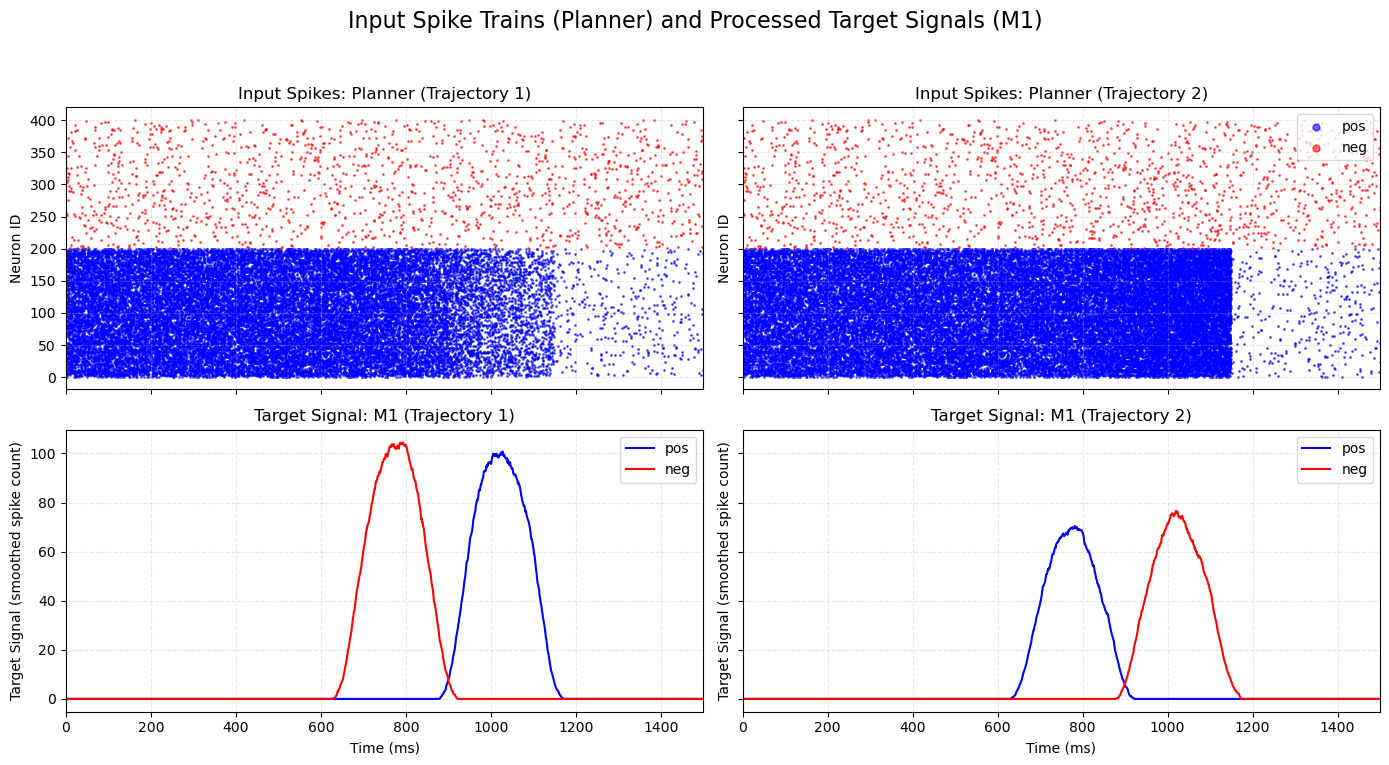

In [3]:
tutorial_plot_trajectories_and_targets(None, target_files, params)

## 3. Run Simulation

Run the SNN simulation. Output is a dictionary with spike times, readout signals, loss curve, durations, and neuron IDs for further analysis.

Using 'rb_neuron' for RBF implementation.

Dec 02 11:56:22 correlation_detector [Info]: 
    Default for delta_tau changed from 0.5 to 5 ms

Dec 02 11:56:22 correlomatrix_detector [Info]: 
    Default for delta_tau changed from 0.5 to 5 ms

Dec 02 11:56:22 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 1 ms

Dec 02 11:56:22 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 1 ms.
motor_neuron_module installed successfully.
rb_neuron simulation_steps: 600002, duration['sim']: 600001.0
rb_neuron sdev set to: 3600.0

Dec 02 11:56:22 Install [Info]: 
    loaded module 
    /home/shimoura/Documents/GitHub/motor-controller-model/motor_controller_model/nestml_neurons/nestml_install/motor_neuron_module.so


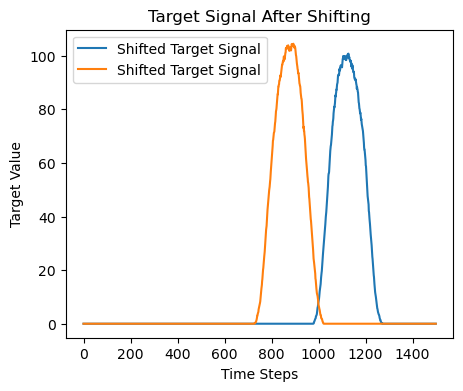

Using spike input mode with rb_neurons.
Setting desired rates for rb_neurons (spike input): [    0.          3157.89473684  6315.78947368  9473.68421053
 12631.57894737 15789.47368421 18947.36842105 22105.26315789
 25263.15789474 28421.05263158 31578.94736842 34736.84210526
 37894.73684211 41052.63157895 44210.52631579 47368.42105263
 50526.31578947 53684.21052632 56842.10526316 60000.        ]
Starting simulation for 600001.00 ms... (sequences per iter incl. silence: 400; update interval: 1500.0 ms; gradient_batch_size=1; expected weight updates ≈ 400.0)

Dec 02 11:56:58 NodeManager::prepare_nodes [Info]: 
    Preparing 2354 nodes for simulation.

Dec 02 11:56:58 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 2354
    Simulation time (ms): 600001
    Number of OpenMP threads: 4
    Not using MPI

Dec 02 11:59:05 SimulationManager::run [Info]: 
    Simulation finished.
Simulation finished.
Saving trained weights...
Trained weights saved.
Generating and saving pl

/home/shimoura/Documents/GitHub/motor-controller-model/motor_controller_model/plot_results.py:454: UserWarning:This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


Results saved to ./tutorial_results


In [4]:
results = run_simulation(**params)
# results contains:
#   - 'spikes': {'senders', 'times'}
#   - 'output_multimeter': {'senders', 'times', 'readout_signal', 'target_signal'}
#   - 'loss': training loss curve
#   - 'duration': timing info for analysis windows
#   - 'nrns_rec': recurrent neuron IDs (NEST NodeCollection or array)

## 4. Define Analysis Windows: Pre- and Post-Training

We analyze network behavior before and after training (following conventions in [`eprop-motor-control/plot_results.py`](https://github.com/shimoura/motor-controller-model/blob/add-nestml-neurons/eprop-motor-control/plot_results.py)).

In [5]:
duration = results['duration']
n_trajectories = duration['n_trajectories']

print(f"n_trajectories: {n_trajectories}")
print(f"task duration: {duration['task']}")
print(f"total_sequence_with_silence: {duration['total_sequence_with_silence']}")

# Pre-training: first trajectories
pre_train_window = (0, n_trajectories * duration['total_sequence_with_silence'])
# Post-training: last trajectories
post_train_window = (
    duration['task'] - n_trajectories * duration['total_sequence_with_silence'],
    duration['task']
)
xlims_list = [pre_train_window, post_train_window]

print(f"\nPre-training window: {pre_train_window}")
print(f"Post-training window: {post_train_window}")

n_trajectories: 2
task duration: 600000.0
total_sequence_with_silence: 1500.0

Pre-training window: (0, 3000.0)
Post-training window: (597000.0, 600000.0)


## 5. Spike Raster Plot: Pre- and Post-Training

Visualize firing activity of recurrent neurons (M1 population) before and after learning. Observe changes in network temporal patterns and structure.

> **Note:** Spike rasters reveal emergent population dynamics. Structured activity after training may reflect the network's ability to encode and generate motor commands for the task.

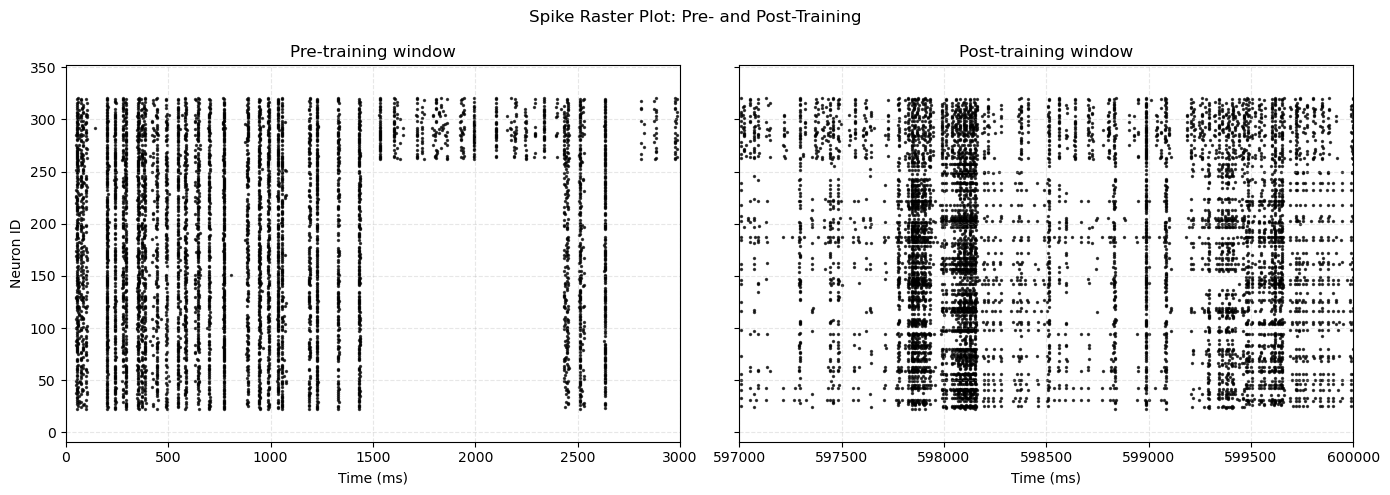

In [6]:
tutorial_plot_spike_raster(results['spikes'], results['nrns_rec'], xlims_list)

## 6. Output vs Target Signal: Pre- and Post-Training

Compare actual network outputs to target signals for motor control ("pos"/"neg" channels). Assess learning progress and output channel accuracy.

> **Note:** Output neurons represent motor command signals. Accurate matching to targets after learning is key for effective movement control.

/home/shimoura/Documents/GitHub/motor-controller-model/motor_controller_model/plot_results.py:780: UserWarning:This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


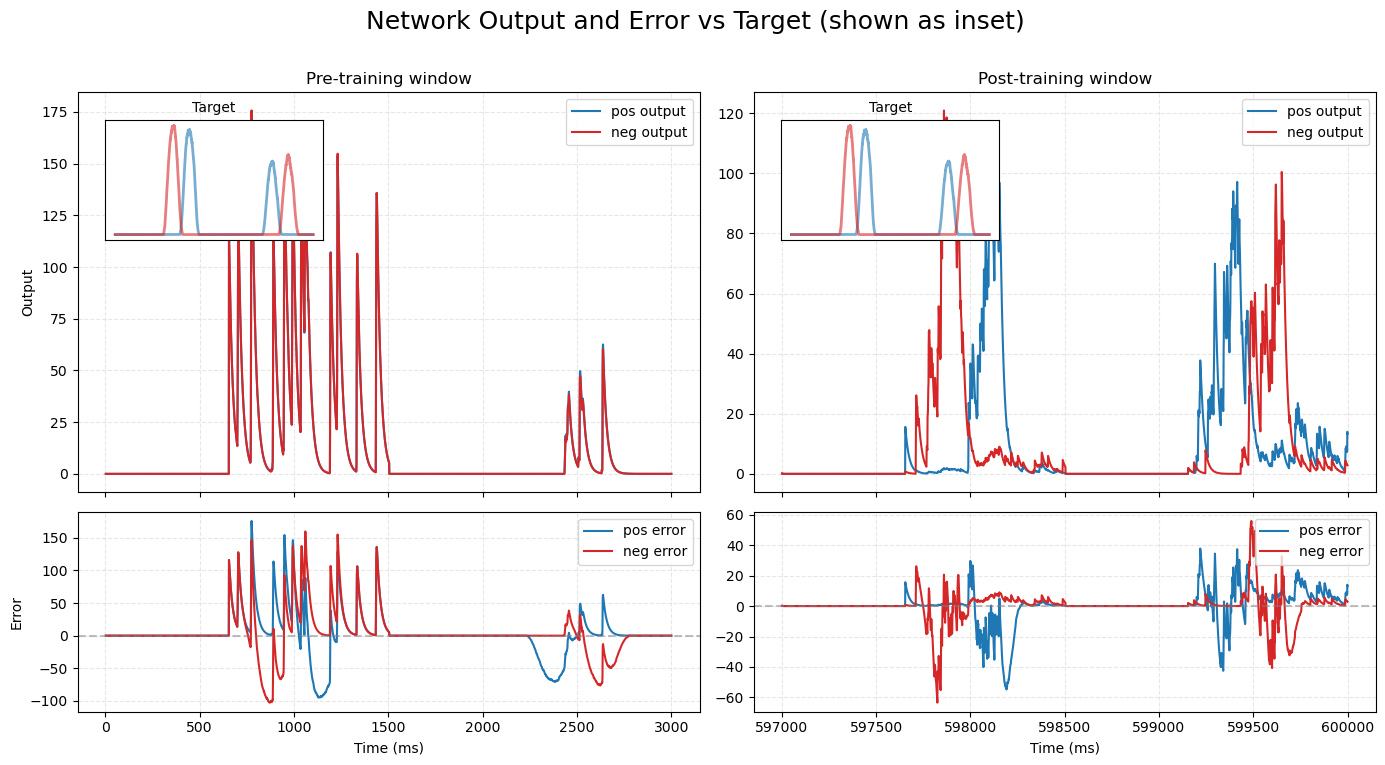

In [7]:
tutorial_plot_output_vs_target(results['output_multimeter'], xlims_list)

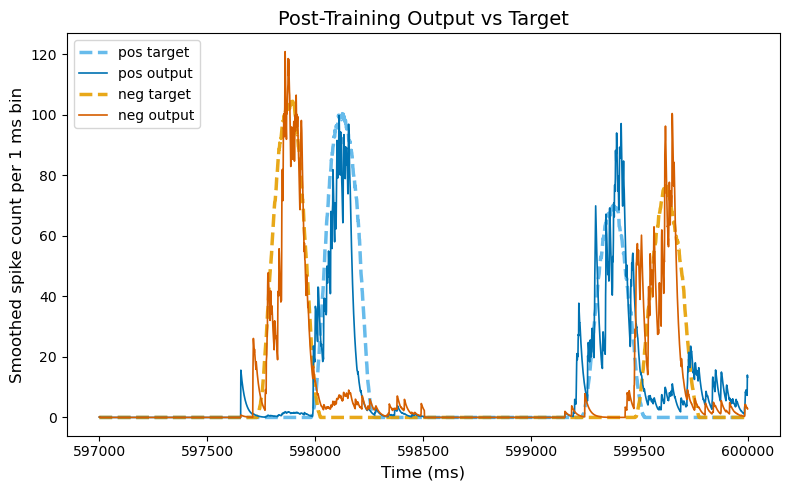

In [8]:
tutorial_plot_post_training_output_vs_target(results['output_multimeter'], post_train_window)

## 7. Training Loss Curve

Track the network's learning progress. A decreasing loss curve reflects successful synaptic adaptation and improved task performance.

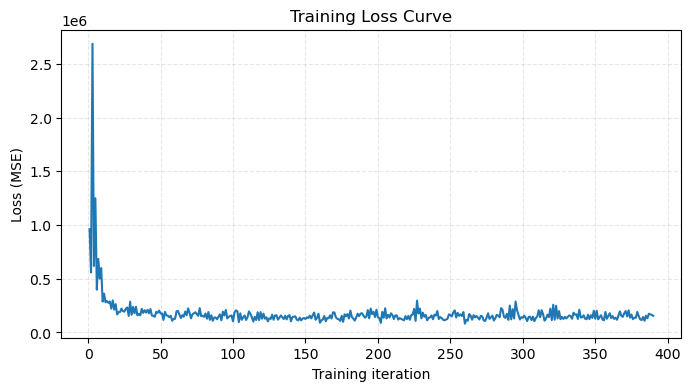

In [9]:
tutorial_plot_loss_curve(results['loss'][10:])

## Further Reading & References

- [NEST Simulator e-prop documentation](https://nest-simulator.readthedocs.io/en/stable/auto_examples/eprop_plasticity/index.html)
- [NESTML documentation](https://nestml.readthedocs.io/en/latest/)
- Bellec G et al. (2020), Nature Communications: [A solution to the learning dilemma for recurrent networks of spiking neurons](https://doi.org/10.1038/s41467-020-17236-y)
- Pouget, A., Dayan, P., & Zemel, R. (2000). Information processing with population codes. *Nature Reviews Neuroscience*, 1(2), 125-132.
- Georgopoulos, A. P., et al. (1986). Neuronal population coding of movement direction. *Science*, 233(4771), 1416-1419.